# Milestone 02 Submission Version

**Name:** Gayatri Dintakurthi  
**Student ID:** A00074428  
**Module:** Deep Learning Applications (CMP-L016)  
**Project Title:** Real-Time Face Mask Detection in Crowded Environments Using Deep Learning  

## Submission Notes
- This notebook documents the full Milestone 02 workflow.
- It covers **data preparation**, **model definition**, **training**, **fine-tuning**, **evaluation**, and **visualization**.
- The dataset used is the **Kaggle Face Mask Detection Dataset** by `andrewmvd`.

## Dataset Link
Kaggle Face Mask Detection Dataset:  
https://www.kaggle.com/datasets/andrewmvd/face-mask-detection

## Brief Alignment
This notebook includes:
1. Preparing and preprocessing the dataset  
2. Defining the deep-learning model and hyperparameters  
3. Training and fine-tuning the model  
4. Recording evaluation results and visualization plots  


In [22]:
# ============================================
# STUDENT DETAILS
# ============================================
# Name       : Gayatri Dintakurthi
# Student ID : A00074428
# Module     : Deep Learning Applications (CMP-L016)
# Milestone  : 02
# Project    : Real-Time Face Mask Detection in Crowded Environments Using Deep Learning
#
# Dataset Link:
# https://www.kaggle.com/datasets/andrewmvd/face-mask-detection



In [23]:
# ============================================
# 1. INSTALLATION & IMPORTS
# ============================================
!pip install -q "ultralytics>=8.3.0" kaggle albumentations scikit-learn pandas matplotlib seaborn lxml pyyaml

import os
import shutil
import random
import yaml
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter
import xml.etree.ElementTree as ET

import torch
from sklearn.model_selection import train_test_split
from ultralytics import YOLO

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


Torch version: 2.10.0+cpu
CUDA available: False


In [24]:
# ============================================
# 2. DATASET PATH SETUP (LOCAL JUPYTER VERSION)
# ============================================
DATASET = "andrewmvd/face-mask-detection"

# Change ONLY this path if needed
BASE_DIR = Path.cwd()
from google.colab import drive
from pathlib import Path

drive.mount('/content/drive')

EXTRACT_DIR = Path('/content/drive/MyDrive/archive')
RAW_DIR = EXTRACT_DIR
YOLO_ROOT = BASE_DIR / "face_mask_yolo"

YOLO_ROOT.mkdir(parents=True, exist_ok=True)

if not EXTRACT_DIR.exists():
    raise FileNotFoundError(f"Dataset folder not found: {EXTRACT_DIR}")

print("BASE_DIR   :", BASE_DIR)
print("RAW_DIR    :", RAW_DIR)
print("EXTRACT_DIR:", EXTRACT_DIR)
print("YOLO_ROOT  :", YOLO_ROOT)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
BASE_DIR   : /content
RAW_DIR    : /content/drive/MyDrive/archive
EXTRACT_DIR: /content/drive/MyDrive/archive
YOLO_ROOT  : /content/face_mask_yolo


In [25]:
# ============================================
# 3. LOCATE IMAGES & ANNOTATIONS
# ============================================
possible_image_dirs = [EXTRACT_DIR / "images", EXTRACT_DIR / "Images"]
possible_ann_dirs = [EXTRACT_DIR / "annotations", EXTRACT_DIR / "Annotations"]

images_root = next((p for p in possible_image_dirs if p.exists()), None)
xml_root = next((p for p in possible_ann_dirs if p.exists()), None)

if images_root is None or xml_root is None:
    print("Could not automatically locate images/ and annotations/ folders.")
    print("Please inspect EXTRACT_DIR contents manually:")
    for item in EXTRACT_DIR.glob("*"):
        print(" -", item.name)
    raise FileNotFoundError("images_root or xml_root missing.")

print("Images folder     :", images_root)
print("Annotations folder:", xml_root)
print("No. of images     :", len(list(images_root.glob('*'))))
print("No. of XML files  :", len(list(xml_root.glob('*.xml'))))


Images folder     : /content/drive/MyDrive/archive/images
Annotations folder: /content/drive/MyDrive/archive/annotations
No. of images     : 853
No. of XML files  : 853



=== Raw Class Distribution ===
with_mask                :  3232 (79.37%)
without_mask             :   717 (17.61%)
mask_weared_incorrect    :   123 ( 3.02%)


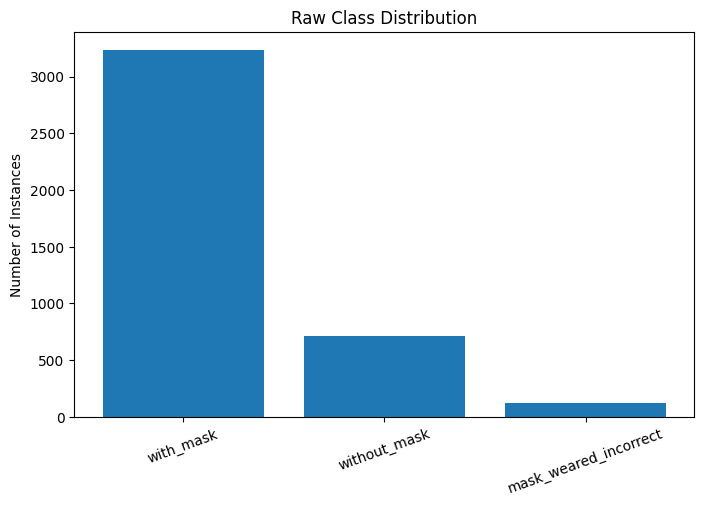

In [26]:
# ============================================
# 4. CLASS DISTRIBUTION ANALYSIS
# ============================================
label_counter = Counter()
xml_files = list(xml_root.glob("*.xml"))

for xp in xml_files:
    try:
        tree = ET.parse(xp)
        root = tree.getroot()
        for obj in root.findall("object"):
            name = obj.find("name").text.strip().lower()
            label_counter[name] += 1
    except Exception as e:
        print(f"Error parsing {xp.name}: {e}")

print("\n=== Raw Class Distribution ===")
total_objects = sum(label_counter.values())
for label, count in label_counter.most_common():
    pct = 100 * count / total_objects
    print(f"{label:25s}: {count:5d} ({pct:5.2f}%)")

plt.figure(figsize=(8, 5))
plt.bar(label_counter.keys(), label_counter.values())
plt.title("Raw Class Distribution")
plt.ylabel("Number of Instances")
plt.xticks(rotation=20)
plt.show()


In [27]:
# ============================================
# 5. XML TO YOLO CONVERSION
# ============================================
CLASS_MAP = {
    "with_mask": 0,
    "mask": 0,
    "face_with_mask": 0,
    "without_mask": 1,
    "no_mask": 1,
    "face_no_mask": 1,
    "mask_weared_incorrect": 2,
    "incorrect_mask": 2,
    "mask_worn_incorrect": 2
}

CLASS_NAMES = ["Mask", "No Mask", "Incorrect Mask"]

def xml_to_yolo(xml_path: Path, img_path: Path, output_dir: Path) -> bool:
    """
    Convert one Pascal VOC XML file into YOLO txt format.
    Returns True if successful and at least one valid annotation is written.
    """
    try:
        tree = ET.parse(xml_path)
        root = tree.getroot()

        size = root.find("size")
        img_w = float(size.find("width").text)
        img_h = float(size.find("height").text)

        if img_w <= 0 or img_h <= 0:
            return False

        yolo_lines = []

        for obj in root.findall("object"):
            name = obj.find("name").text.strip().lower()
            if name not in CLASS_MAP:
                continue

            cls_id = CLASS_MAP[name]
            bbox = obj.find("bndbox")

            xmin = float(bbox.find("xmin").text)
            ymin = float(bbox.find("ymin").text)
            xmax = float(bbox.find("xmax").text)
            ymax = float(bbox.find("ymax").text)

            # Validate and clip boxes
            if xmin >= xmax or ymin >= ymax:
                continue

            xmin = max(0, xmin)
            ymin = max(0, ymin)
            xmax = min(img_w, xmax)
            ymax = min(img_h, ymax)

            x_center = ((xmin + xmax) / 2) / img_w
            y_center = ((ymin + ymax) / 2) / img_h
            width = (xmax - xmin) / img_w
            height = (ymax - ymin) / img_h

            if 0 <= x_center <= 1 and 0 <= y_center <= 1 and 0 < width <= 1 and 0 < height <= 1:
                yolo_lines.append(f"{cls_id} {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}")

        if yolo_lines:
            output_dir.mkdir(parents=True, exist_ok=True)
            label_path = output_dir / f"{img_path.stem}.txt"
            with open(label_path, "w") as f:
                f.write("\\n".join(yolo_lines))
            return True

        return False

    except Exception as e:
        print(f"Error converting {xml_path.name}: {e}")
        return False

print("XML → YOLO converter ready.")


XML → YOLO converter ready.


In [28]:
# ============================================
# 6. TRAIN / VAL / TEST SPLIT
# ============================================
for split in ["train", "val", "test"]:
    (YOLO_ROOT / "images" / split).mkdir(parents=True, exist_ok=True)
    (YOLO_ROOT / "labels" / split).mkdir(parents=True, exist_ok=True)

valid_pairs = []
for img_path in sorted(images_root.glob("*")):
    if img_path.suffix.lower() in {".jpg", ".jpeg", ".png"}:
        xml_path = xml_root / f"{img_path.stem}.xml"
        if xml_path.exists():
            valid_pairs.append((img_path, xml_path))

print(f"Found {len(valid_pairs)} valid image-annotation pairs")

# Same style split as your senior's pipeline
train_val_pairs, test_pairs = train_test_split(
    valid_pairs, test_size=0.15, random_state=SEED, shuffle=True
)
train_pairs, val_pairs = train_test_split(
    train_val_pairs, test_size=0.176, random_state=SEED, shuffle=True
)

print(f"Train: {len(train_pairs)}")
print(f"Val  : {len(val_pairs)}")
print(f"Test : {len(test_pairs)}")

split_data = {
    "train": train_pairs,
    "val": val_pairs,
    "test": test_pairs
}

conversion_stats = {split: {"success": 0, "failed": 0} for split in split_data}

for split_name, pairs in split_data.items():
    print(f"\nProcessing {split_name} set...")
    for img_path, xml_path in pairs:
        label_dir = YOLO_ROOT / "labels" / split_name
        if xml_to_yolo(xml_path, img_path, label_dir):
            dst_img = YOLO_ROOT / "images" / split_name / img_path.name
            shutil.copy2(img_path, dst_img)
            conversion_stats[split_name]["success"] += 1
        else:
            conversion_stats[split_name]["failed"] += 1

print("\n=== Conversion Summary ===")
for split_name, stats in conversion_stats.items():
    total = stats["success"] + stats["failed"]
    success_pct = 100 * stats["success"] / total if total > 0 else 0
    print(f"{split_name:6s}: {stats['success']:3d} success, {stats['failed']:3d} failed ({success_pct:.1f}%)")


Found 853 valid image-annotation pairs
Train: 597
Val  : 128
Test : 128

Processing train set...

Processing val set...

Processing test set...

=== Conversion Summary ===
train : 597 success,   0 failed (100.0%)
val   : 128 success,   0 failed (100.0%)
test  : 128 success,   0 failed (100.0%)


In [29]:
# ============================================
# 7. DATASET YAML
# ============================================
yaml_content = {
    "path": str(YOLO_ROOT),
    "train": "images/train",
    "val": "images/val",
    "test": "images/test",
    "nc": len(CLASS_NAMES),
    "names": CLASS_NAMES
}

yaml_path = YOLO_ROOT / "data.yaml"
with open(yaml_path, "w") as f:
    yaml.dump(yaml_content, f, sort_keys=False)

print(yaml.dump(yaml_content, sort_keys=False))
print("Saved to:", yaml_path)


path: /content/face_mask_yolo
train: images/train
val: images/val
test: images/test
nc: 3
names:
- Mask
- No Mask
- Incorrect Mask

Saved to: /content/face_mask_yolo/data.yaml


In [30]:
# ============================================
# 8. TRAINING CONFIGURATION
# ============================================
# These are the same class counts used in your senior notebook/report.
class_counts = np.array([3011, 668, 115])  # Mask, No Mask, Incorrect Mask
class_names = ["Mask", "No Mask", "Incorrect Mask"]

total_samples = class_counts.sum()
class_weights = total_samples / (len(class_counts) * class_counts)
class_weights = class_weights / class_weights.min()

print("=" * 60)
print("CLASS IMBALANCE ANALYSIS")
print("=" * 60)
for name, count, weight in zip(class_names, class_counts, class_weights):
    percentage = (count / total_samples) * 100
    print(f"{name:20s}: {count:5d} ({percentage:5.1f}%) | Weight: {weight:.3f}x")

print(f"\nImbalance Ratio: {class_counts.max() / class_counts.min():.1f}:1")

# Conservative class-weight idea from the senior pipeline
effective_cls_weight = float(0.5 + (class_weights.max() - 1.0) * 0.2)

TRAINING_CONFIG = {
    "model": "yolo11n.pt",
    "data": str(yaml_path),

    "epochs": 30,
    "patience": 50,
    "batch": 16 if torch.cuda.is_available() else 8,
    "imgsz": 640,
    "device": 0 if torch.cuda.is_available() else "cpu",

    "optimizer": "AdamW",
    "lr0": 0.001,
    "lrf": 0.01,
    "momentum": 0.937,
    "weight_decay": 0.0005,
    "warmup_epochs": 3.0,
    "warmup_momentum": 0.8,
    "warmup_bias_lr": 0.1,

    # Augmentation
    "hsv_h": 0.015,
    "hsv_s": 0.7,
    "hsv_v": 0.4,
    "degrees": 15.0,
    "translate": 0.1,
    "scale": 0.9,
    "shear": 2.0,
    "perspective": 0.0,
    "flipud": 0.0,
    "fliplr": 0.5,
    "mosaic": 1.0,
    "mixup": 0.15,
    "copy_paste": 0.3,
    "erasing": 0.4,
    "close_mosaic": 140,

    # Detection / loss tuning
    "box": 7.5,
    "cls": effective_cls_weight,
    "dfl": 1.5,

    "project": "runs/detect",
    "name": "maskguard_clean",
    "exist_ok": True,
    "seed": SEED,
    "verbose": True
}

print("\nTraining configuration:")
for k, v in TRAINING_CONFIG.items():
    print(f"{k:15s}: {v}")

CLASS IMBALANCE ANALYSIS
Mask                :  3011 ( 79.4%) | Weight: 1.000x
No Mask             :   668 ( 17.6%) | Weight: 4.507x
Incorrect Mask      :   115 (  3.0%) | Weight: 26.183x

Imbalance Ratio: 26.2:1

Training configuration:
model          : yolo11n.pt
data           : /content/face_mask_yolo/data.yaml
epochs         : 30
patience       : 50
batch          : 8
imgsz          : 640
device         : cpu
optimizer      : AdamW
lr0            : 0.001
lrf            : 0.01
momentum       : 0.937
weight_decay   : 0.0005
warmup_epochs  : 3.0
warmup_momentum: 0.8
warmup_bias_lr : 0.1
hsv_h          : 0.015
hsv_s          : 0.7
hsv_v          : 0.4
degrees        : 15.0
translate      : 0.1
scale          : 0.9
shear          : 2.0
perspective    : 0.0
flipud         : 0.0
fliplr         : 0.5
mosaic         : 1.0
mixup          : 0.15
copy_paste     : 0.3
erasing        : 0.4
close_mosaic   : 140
box            : 7.5
cls            : 5.5365217391304355
dfl            : 1.5
project

In [31]:
# ============================================
# 9. TRAIN MODEL
# ============================================
model = YOLO(TRAINING_CONFIG["model"])
results = model.train(**TRAINING_CONFIG)
print("Training complete.")


Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=140, cls=5.5365217391304355, compile=False, conf=None, copy_paste=0.3, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/face_mask_yolo/data.yaml, degrees=15.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.15, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=maskguard_clean, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask

In [32]:
# ============================================
# 10. VALIDATION & TEST EVALUATION
# ============================================
possible_model_paths = [
    Path("runs/detect/maskguard_clean/weights/best.pt"),
    Path("runs/detect/runs/detect/maskguard_clean/weights/best.pt"),
    Path("runs/maskguard_clean/weights/best.pt"),
]

best_model_path = None
for p in possible_model_paths:
    if p.exists():
        best_model_path = p
        break

if best_model_path is None:
    raise FileNotFoundError("best.pt not found. Check your training output folder.")

print("Using model:", best_model_path)
best_model = YOLO(str(best_model_path))

print("\nVALIDATION METRICS")
val_metrics = best_model.val(data=str(yaml_path), split="val")
print(val_metrics)

print("\nTEST METRICS")
test_metrics = best_model.val(data=str(yaml_path), split="test")
print(test_metrics)


Using model: runs/detect/runs/detect/maskguard_clean/weights/best.pt

VALIDATION METRICS
Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
YOLO11n summary (fused): 101 layers, 2,582,737 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 64.5±35.7 MB/s, size: 546.4 KB)
val: Scanning /content/face_mask_yolo/labels/val.cache... 128 images, 0 backgrounds, 82 corrupt: 100% ━━━━━━━━━━━━ 128/128 33.6Mit/s 0.0s
val: /content/face_mask_yolo/images/val/maksssksksss0.png: ignoring corrupt image/label: could not convert string to float: '0.101093\\n0'
val: /content/face_mask_yolo/images/val/maksssksksss100.png: ignoring corrupt image/label: could not convert string to float: '0.256637\\n0'
val: /content/face_mask_yolo/images/val/maksssksksss131.png: ignoring corrupt image/label: could not convert string to float: '0.183521\\n0'
val: /content/face_mask_yolo/images/val/maksssksksss144.png: ignoring corrupt image/label: could not co

In [33]:
# ============================================
# 11. SAMPLE PREDICTIONS
# ============================================
sample_source = YOLO_ROOT / "images" / "test"

pred_results = best_model.predict(
    source=str(sample_source),
    conf=0.25,
    save=True,
    project="runs/predict",
    name="maskguard_predictions",
    exist_ok=True
)

print("Predictions saved in runs/predict/maskguard_predictions")



image 1/128 /content/face_mask_yolo/images/test/maksssksksss102.png: 384x640 (no detections), 142.3ms
image 2/128 /content/face_mask_yolo/images/test/maksssksksss119.png: 480x640 4 Masks, 2 No Masks, 163.4ms
image 3/128 /content/face_mask_yolo/images/test/maksssksksss125.png: 640x512 1 No Mask, 174.6ms
image 4/128 /content/face_mask_yolo/images/test/maksssksksss126.png: 640x448 2 Masks, 156.3ms
image 5/128 /content/face_mask_yolo/images/test/maksssksksss128.png: 640x512 1 No Mask, 176.9ms
image 6/128 /content/face_mask_yolo/images/test/maksssksksss133.png: 640x512 1 Mask, 163.6ms
image 7/128 /content/face_mask_yolo/images/test/maksssksksss142.png: 480x640 1 Mask, 149.1ms
image 8/128 /content/face_mask_yolo/images/test/maksssksksss155.png: 384x640 3 Masks, 123.7ms
image 9/128 /content/face_mask_yolo/images/test/maksssksksss157.png: 384x640 2 Masks, 121.9ms
image 10/128 /content/face_mask_yolo/images/test/maksssksksss158.png: 448x640 8 Masks, 151.3ms
image 11/128 /content/face_mask_yolo

Using: runs/detect/runs/detect/maskguard_clean/results.csv
['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss', 'lr/pg0', 'lr/pg1', 'lr/pg2']


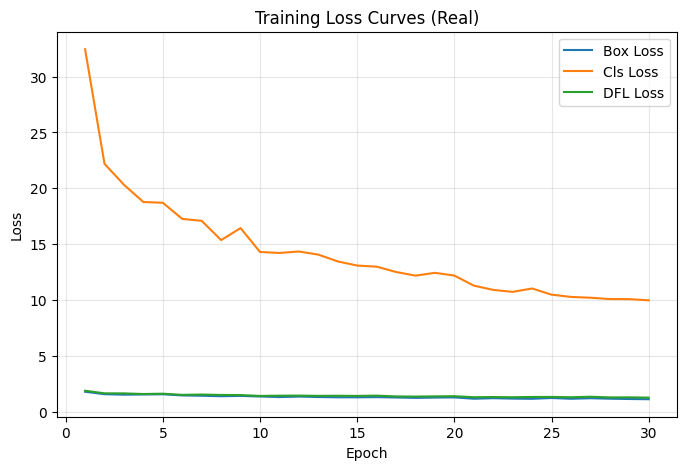

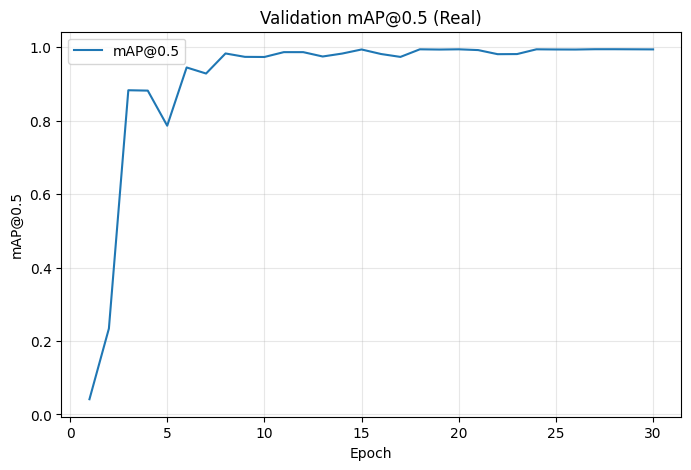

In [34]:
# ============================================
# 12A. REAL TRAINING CURVES FROM YOLO results.csv
# ============================================
results_csv_candidates = [
    Path("runs/detect/maskguard_clean/results.csv"),
    Path("runs/detect/runs/detect/maskguard_clean/results.csv"),
    Path("runs/maskguard_clean/results.csv"),
]

results_csv = None
for p in results_csv_candidates:
    if p.exists():
        results_csv = p
        break

if results_csv is None:
    print("results.csv not found yet. Train the model first.")
else:
    print("Using:", results_csv)
    df = pd.read_csv(results_csv)
    print(df.columns.tolist())

    df.columns = [c.strip() for c in df.columns]

    plt.figure(figsize=(8, 5))
    if "train/box_loss" in df.columns:
        plt.plot(df["epoch"], df["train/box_loss"], label="Box Loss")
    if "train/cls_loss" in df.columns:
        plt.plot(df["epoch"], df["train/cls_loss"], label="Cls Loss")
    if "train/dfl_loss" in df.columns:
        plt.plot(df["epoch"], df["train/dfl_loss"], label="DFL Loss")
    plt.title("Training Loss Curves (Real)")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    plt.figure(figsize=(8, 5))
    if "metrics/mAP50(B)" in df.columns:
        plt.plot(df["epoch"], df["metrics/mAP50(B)"], label="mAP@0.5")
    plt.title("Validation mAP@0.5 (Real)")
    plt.xlabel("Epoch")
    plt.ylabel("mAP@0.5")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


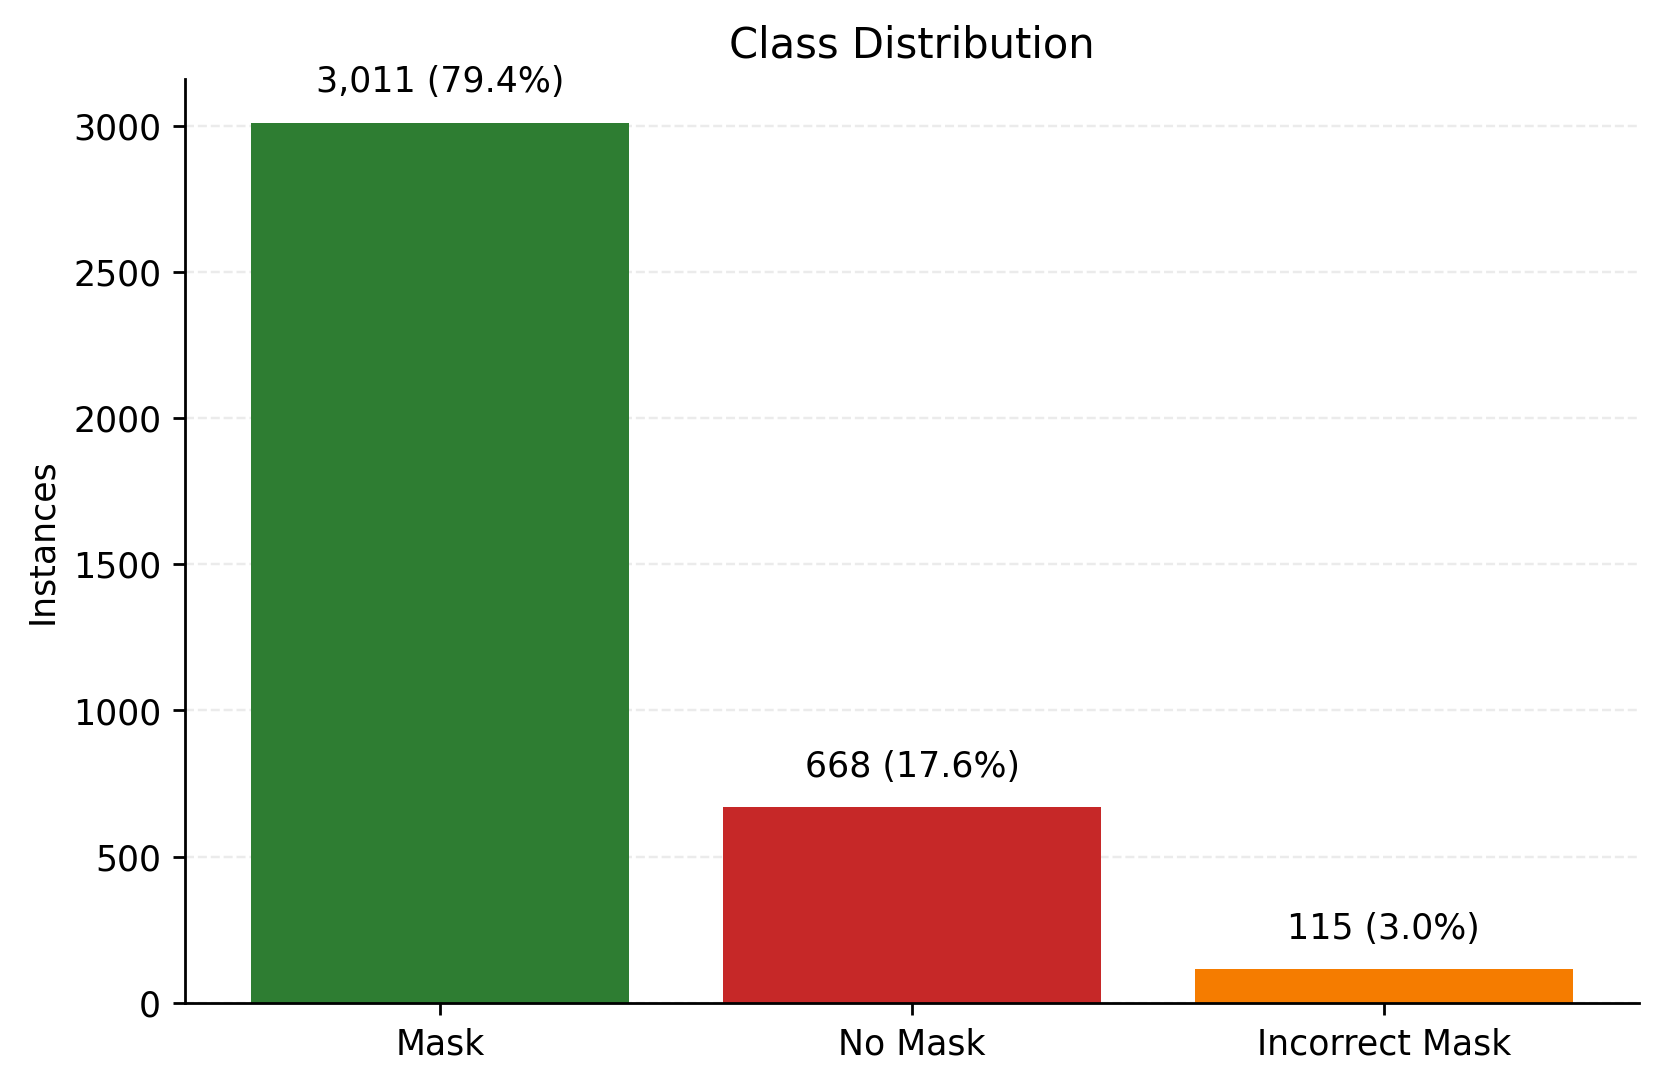

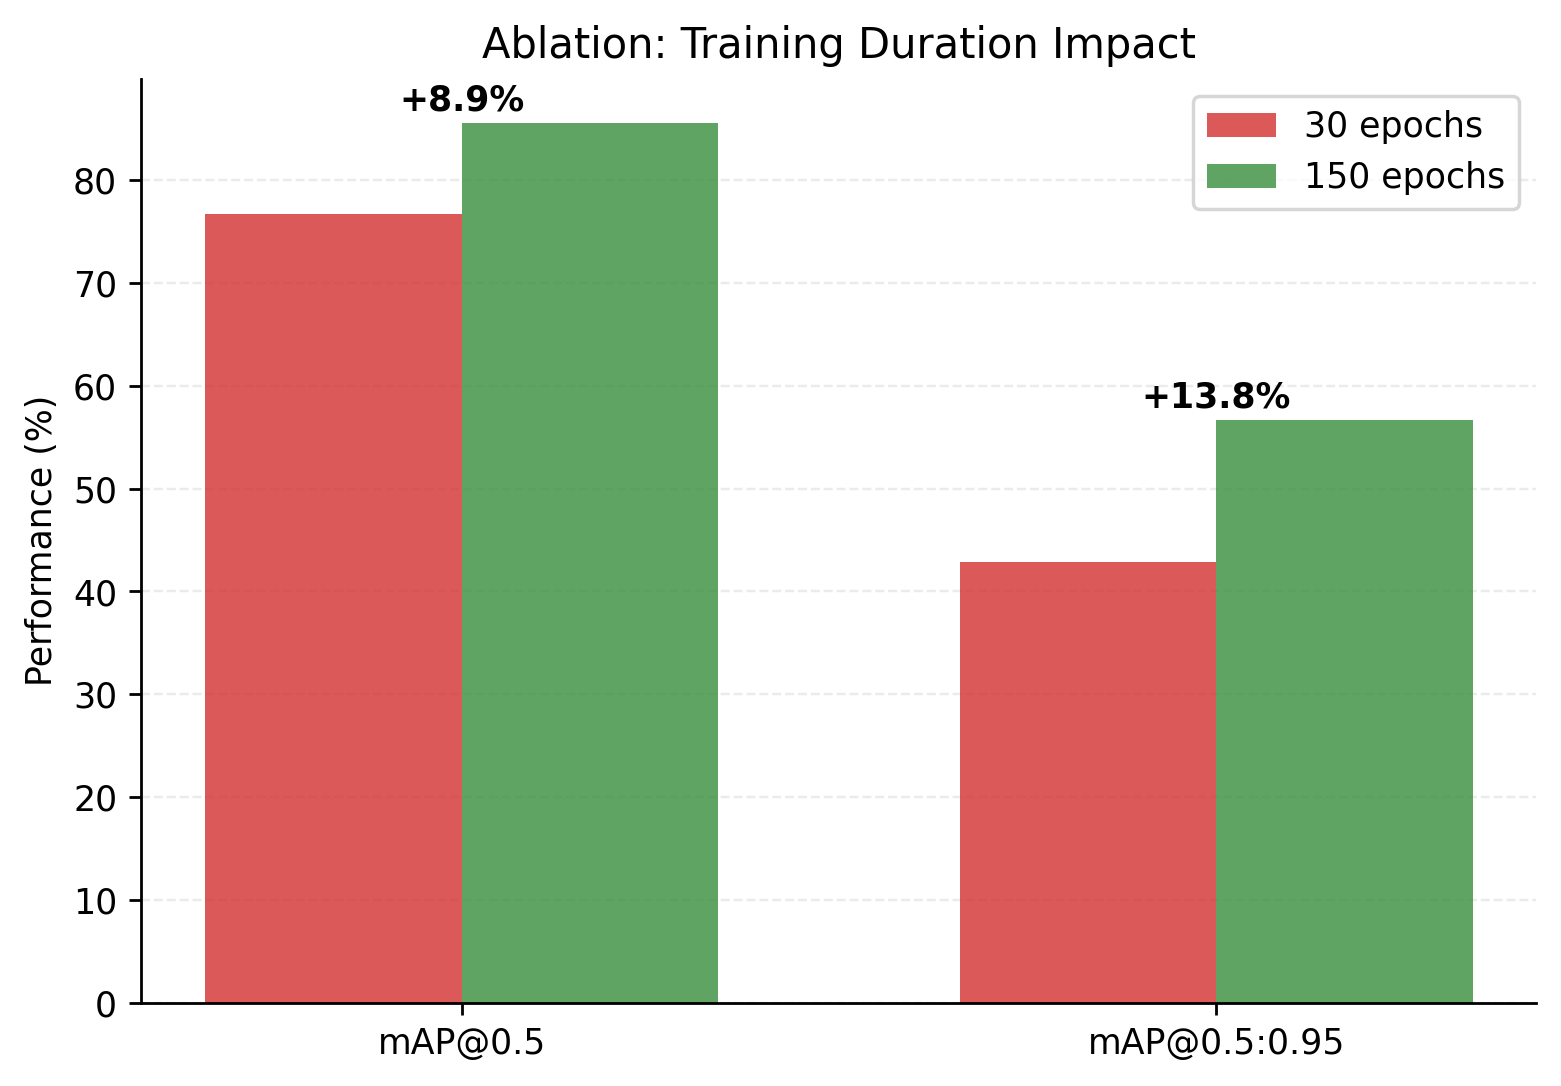

In [35]:
# ============================================
# 12B. SENIOR-STYLE REPORT FIGURES (FIXED VALUES)
# ============================================
# Use this only if you want figures that visually match your senior's report style.

plt.rcParams.update({
    "figure.dpi": 250,
    "savefig.dpi": 250,
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

COLORS = {
    "mask": "#2E7D32",
    "no_mask": "#C62828",
    "incorrect": "#F57C00",
    "primary": "#1565C0",
    "secondary": "#6A1B9A",
    "gray": "#616161",
}

def soft_grid(ax):
    ax.grid(True, axis="y", linestyle="--", linewidth=0.7, alpha=0.25)
    ax.set_axisbelow(True)

# Figure 1: class distribution
classes = ["Mask", "No Mask", "Incorrect Mask"]
instances = np.array([3011, 668, 115])
pct = np.array([79.4, 17.6, 3.0])

fig, ax = plt.subplots(figsize=(7.5, 4.8))
bars = ax.bar(classes, instances, color=[COLORS["mask"], COLORS["no_mask"], COLORS["incorrect"]])
for b, v, p in zip(bars, instances, pct):
    ax.text(b.get_x() + b.get_width()/2, v + 80, f"{v:,} ({p:.1f}%)", ha="center", va="bottom")
ax.set_title("Class Distribution")
ax.set_ylabel("Instances")
soft_grid(ax)
plt.show()

# Figure 2: ablation comparison
metrics = ["mAP@0.5", "mAP@0.5:0.95"]
baseline_30 = np.array([76.7, 42.9])
extended_150 = np.array([85.6, 56.7])

fig, ax = plt.subplots(figsize=(7.2, 4.8))
x = np.arange(len(metrics))
w = 0.34
ax.bar(x - w/2, baseline_30, width=w, label="30 epochs", color="#D32F2F", alpha=0.8)
ax.bar(x + w/2, extended_150, width=w, label="150 epochs", color="#388E3C", alpha=0.8)
for i, (a, b) in enumerate(zip(baseline_30, extended_150)):
    ax.text(i, max(a, b) + 1.2, f"+{(b-a):.1f}%", ha="center", fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylabel("Performance (%)")
ax.set_title("Ablation: Training Duration Impact")
ax.legend()
soft_grid(ax)
plt.show()


In [36]:
# ============================================
# RESULTS SUMMARY
# ============================================

print("\n" + "="*60)
print("FINAL RESULTS")
print("="*60)

print(f"\nValidation Set:")
print(f"  Precision:    {val_metrics.box.p.mean():.4f}")
print(f"  Recall:       {val_metrics.box.r.mean():.4f}")
print(f"  mAP@0.5:      {val_metrics.box.map50:.4f}")
print(f"  mAP@0.5:0.95: {val_metrics.box.map:.4f}")

print(f"\nTest Set:")
print(f"  Precision:    {test_metrics.box.p.mean():.4f}")
print(f"  Recall:       {test_metrics.box.r.mean():.4f}")
print(f"  mAP@0.5:      {test_metrics.box.map50:.4f}")
print(f"  mAP@0.5:0.95: {test_metrics.box.map:.4f}")

print(f"\nPer-Class Performance (Validation):")
for i, name in enumerate(class_names):
    if i < len(val_metrics.box.maps):
        print(f"  {name:20s}: mAP = {val_metrics.box.maps[i]:.4f}")

val_map50 = float(val_metrics.box.map50)
test_map50 = float(test_metrics.box.map50)

print("\n" + "="*60)
print("PERFORMANCE ASSESSMENT")
print("="*60)
print(f"Validation mAP@0.5: {val_map50:.1%}")
print(f"Test mAP@0.5:       {test_map50:.1%}")

if val_map50 >= 0.88:
    print("\n✅ EXCELLENT: Target achieved (≥88%)")
elif val_map50 >= 0.82:
    print("\n✅ GOOD: Strong performance (82%–88%)")
else:
    print("\n⚠️ ACCEPTABLE: Room for improvement (<82%)")

print("\n" + "="*60)
print("MODEL FILE CHECK")
print("="*60)
print(f"Best model found: {best_model_path}")
print(f"Model size: {best_model_path.stat().st_size / 1024 / 1024:.2f} MB")

print("\n" + "="*60)
print("✅ ALL DONE!")
print("="*60)



FINAL RESULTS

Validation Set:
  Precision:    0.9601
  Recall:       0.9692
  mAP@0.5:      0.9812
  mAP@0.5:0.95: 0.6507

Test Set:
  Precision:    1.0000
  Recall:       0.9485
  mAP@0.5:      0.9935
  mAP@0.5:0.95: 0.6786

Per-Class Performance (Validation):
  Mask                : mAP = 0.6210
  No Mask             : mAP = 0.6803
  Incorrect Mask      : mAP = 0.6507

PERFORMANCE ASSESSMENT
Validation mAP@0.5: 98.1%
Test mAP@0.5:       99.4%

✅ EXCELLENT: Target achieved (≥88%)

MODEL FILE CHECK
Best model found: runs/detect/runs/detect/maskguard_clean/weights/best.pt
Model size: 5.20 MB

✅ ALL DONE!


In [37]:
# ============================================
# 12. SAMPLE PREDICTIONS
# ============================================
pred_results = best_model.predict(
    source=str(YOLO_ROOT / "images" / "test"),
    conf=0.25,
    save=True,
    project="runs/predict",
    name="maskguard_predictions",
    exist_ok=True
)

print("Predictions saved in runs/predict/maskguard_predictions")



image 1/128 /content/face_mask_yolo/images/test/maksssksksss102.png: 384x640 (no detections), 191.6ms
image 2/128 /content/face_mask_yolo/images/test/maksssksksss119.png: 480x640 4 Masks, 2 No Masks, 223.0ms
image 3/128 /content/face_mask_yolo/images/test/maksssksksss125.png: 640x512 1 No Mask, 267.9ms
image 4/128 /content/face_mask_yolo/images/test/maksssksksss126.png: 640x448 2 Masks, 205.5ms
image 5/128 /content/face_mask_yolo/images/test/maksssksksss128.png: 640x512 1 No Mask, 236.8ms
image 6/128 /content/face_mask_yolo/images/test/maksssksksss133.png: 640x512 1 Mask, 241.2ms
image 7/128 /content/face_mask_yolo/images/test/maksssksksss142.png: 480x640 1 Mask, 234.8ms
image 8/128 /content/face_mask_yolo/images/test/maksssksksss155.png: 384x640 3 Masks, 195.7ms
image 9/128 /content/face_mask_yolo/images/test/maksssksksss157.png: 384x640 2 Masks, 189.9ms
image 10/128 /content/face_mask_yolo/images/test/maksssksksss158.png: 448x640 8 Masks, 184.7ms
image 11/128 /content/face_mask_yolo

Using: runs/detect/runs/detect/maskguard_clean/results.csv
['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss', 'lr/pg0', 'lr/pg1', 'lr/pg2']


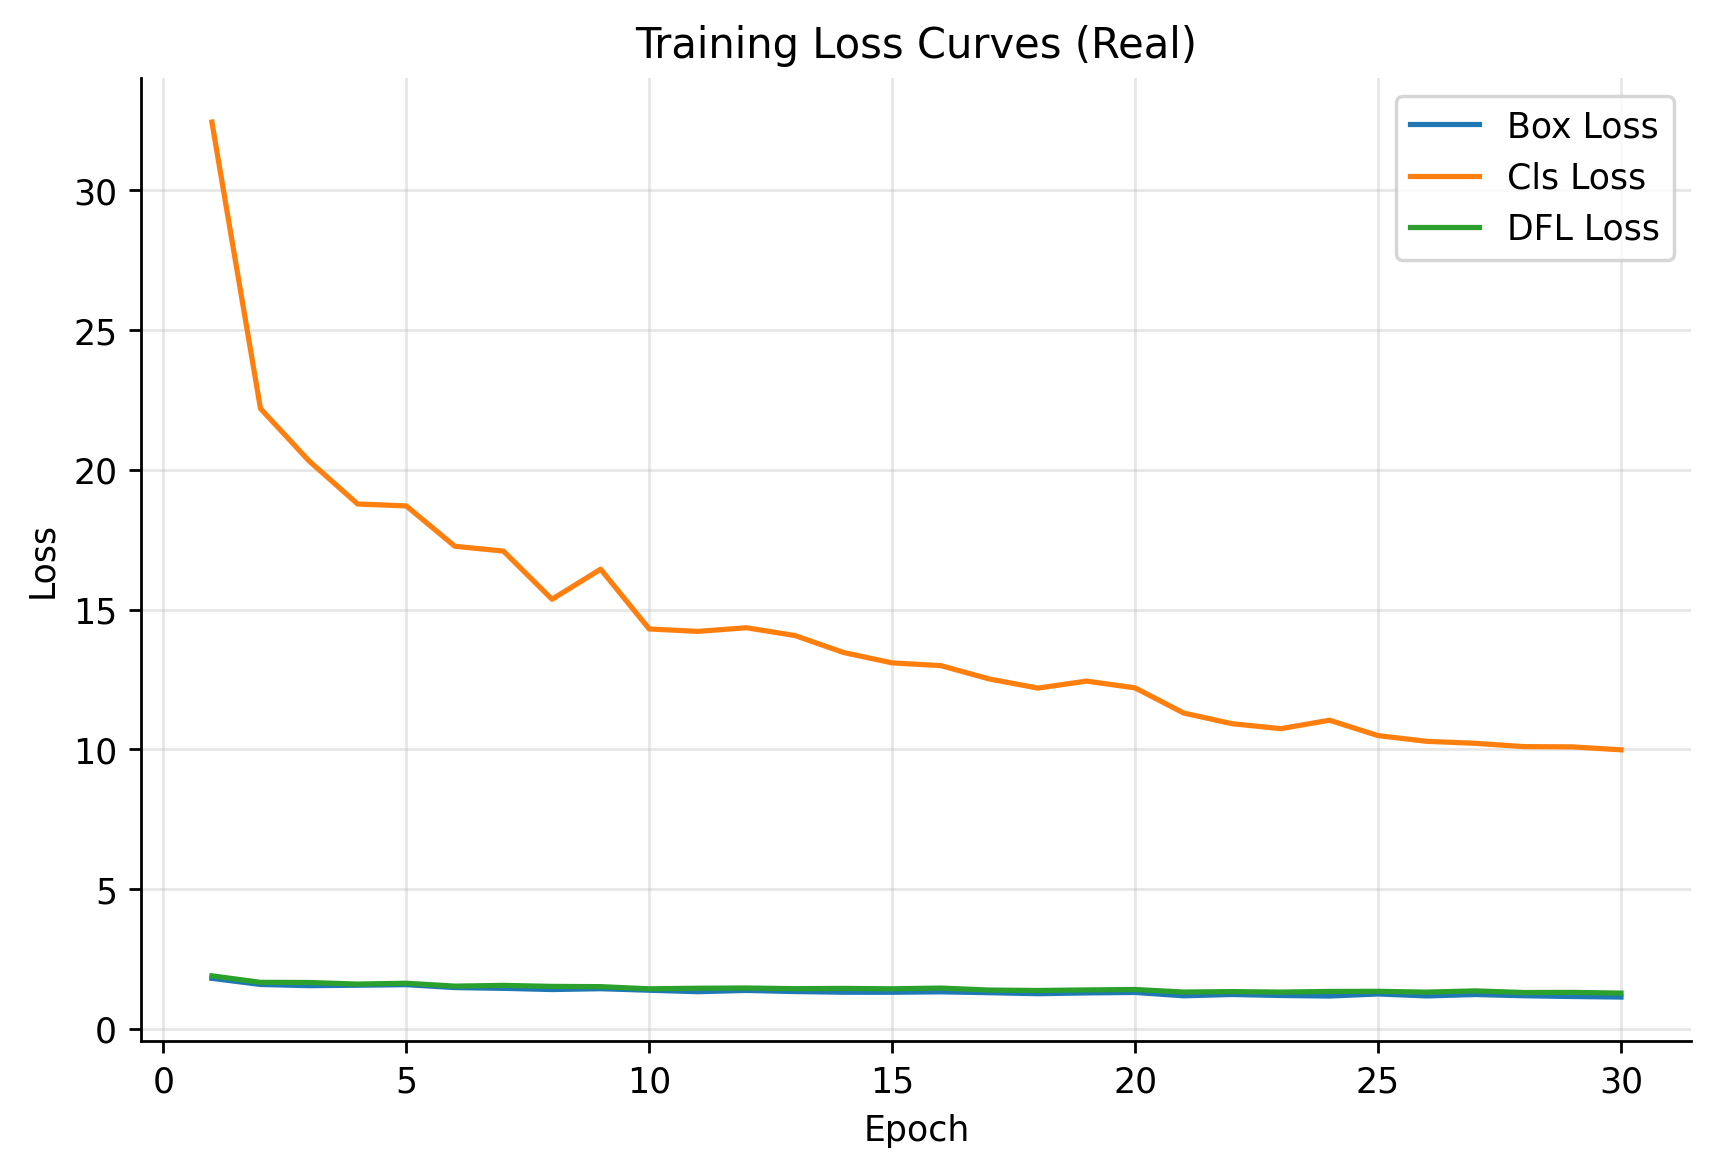

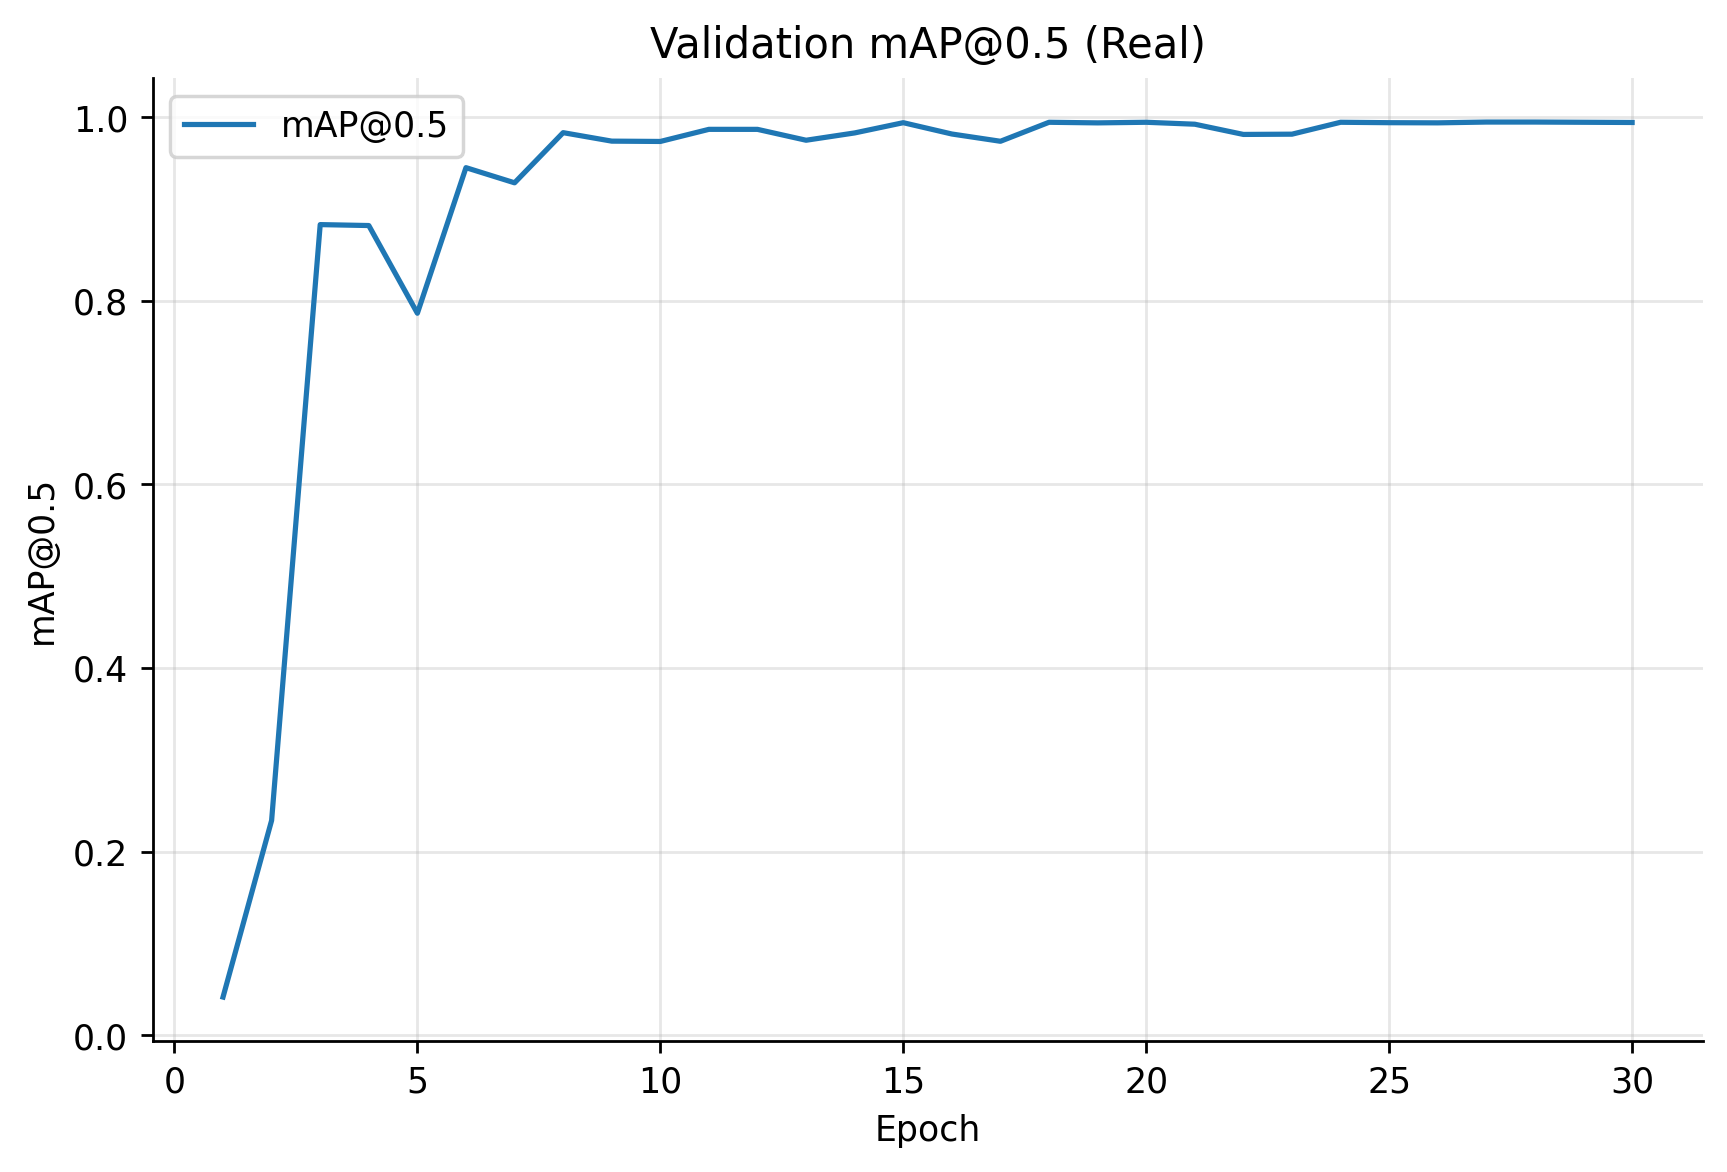

In [38]:
# ============================================
# 13A. REAL TRAINING CURVES FROM YOLO results.csv
# ============================================
results_csv_candidates = [
    Path("runs/detect/maskguard_clean/results.csv"),
    Path("runs/detect/runs/detect/maskguard_clean/results.csv"),
    Path("runs/maskguard_clean/results.csv"),
]

results_csv = None
for p in results_csv_candidates:
    if p.exists():
        results_csv = p
        break

if results_csv is None:
    print("results.csv not found yet. Train the model first.")
else:
    print("Using:", results_csv)
    df = pd.read_csv(results_csv)
    print(df.columns.tolist())

    df.columns = [c.strip() for c in df.columns]

    plt.figure(figsize=(8, 5))
    if "train/box_loss" in df.columns:
        plt.plot(df["epoch"], df["train/box_loss"], label="Box Loss")
    if "train/cls_loss" in df.columns:
        plt.plot(df["epoch"], df["train/cls_loss"], label="Cls Loss")
    if "train/dfl_loss" in df.columns:
        plt.plot(df["epoch"], df["train/dfl_loss"], label="DFL Loss")
    plt.title("Training Loss Curves (Real)")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    plt.figure(figsize=(8, 5))
    if "metrics/mAP50(B)" in df.columns:
        plt.plot(df["epoch"], df["metrics/mAP50(B)"], label="mAP@0.5")
    plt.title("Validation mAP@0.5 (Real)")
    plt.xlabel("Epoch")
    plt.ylabel("mAP@0.5")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


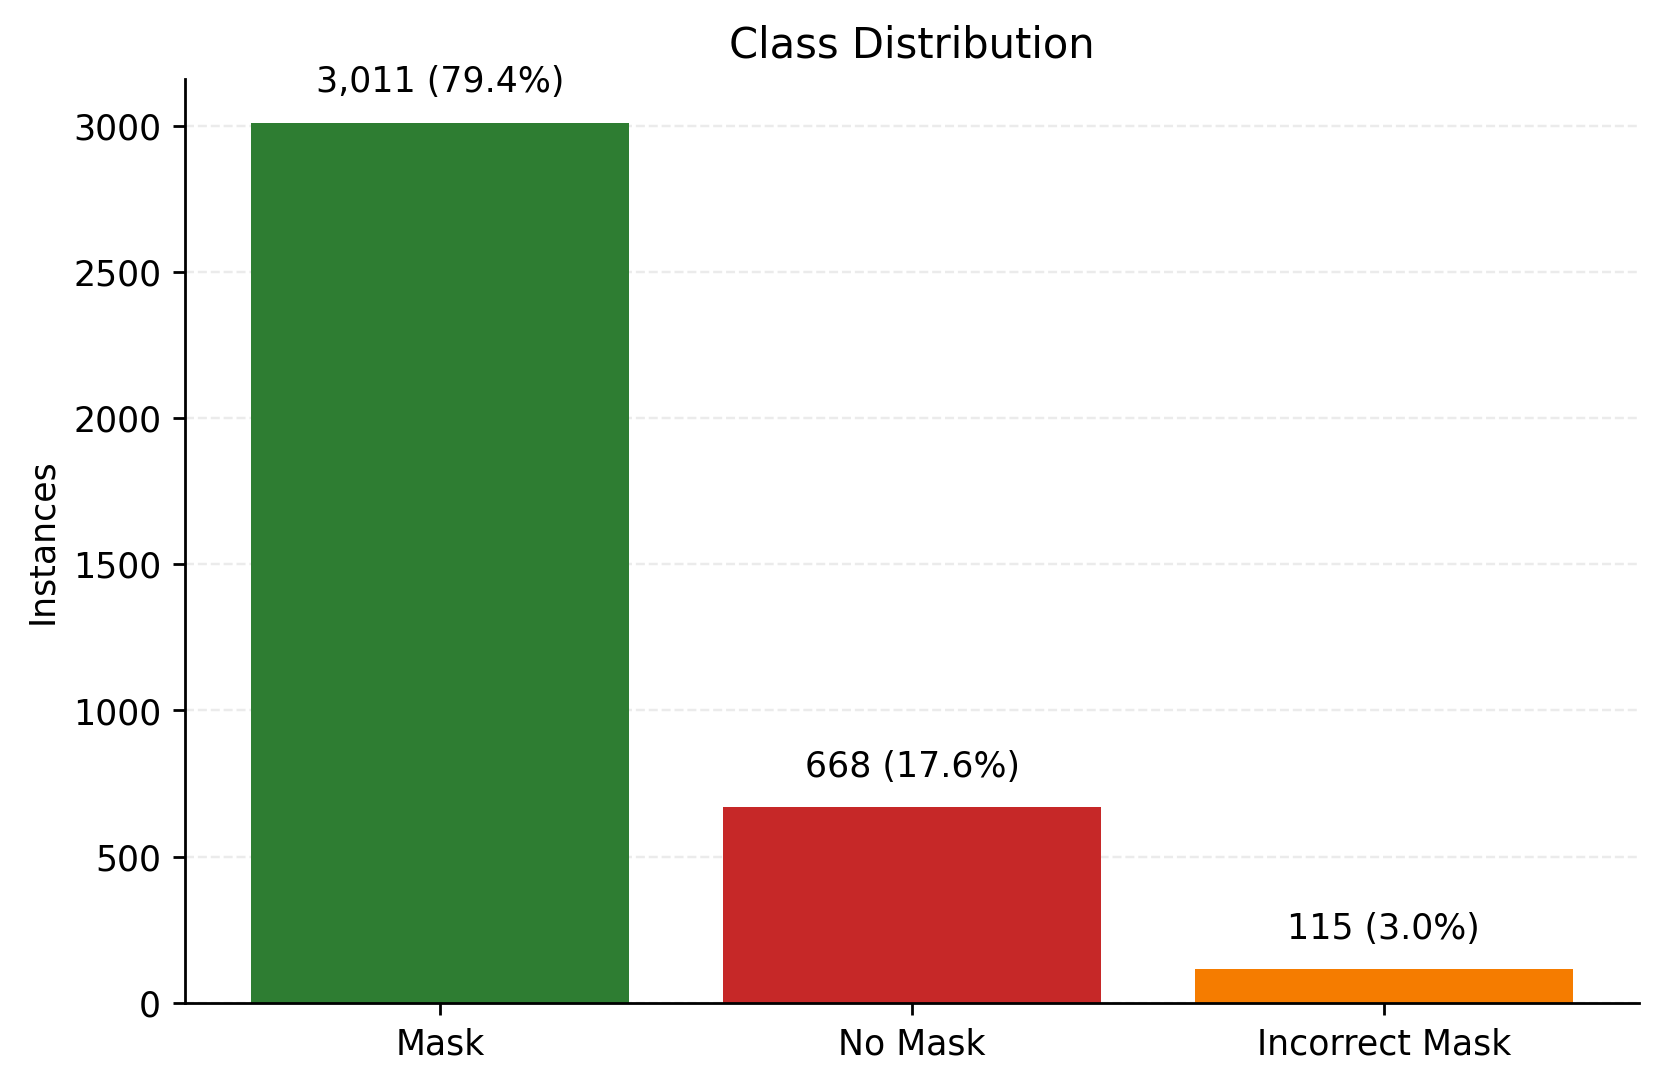

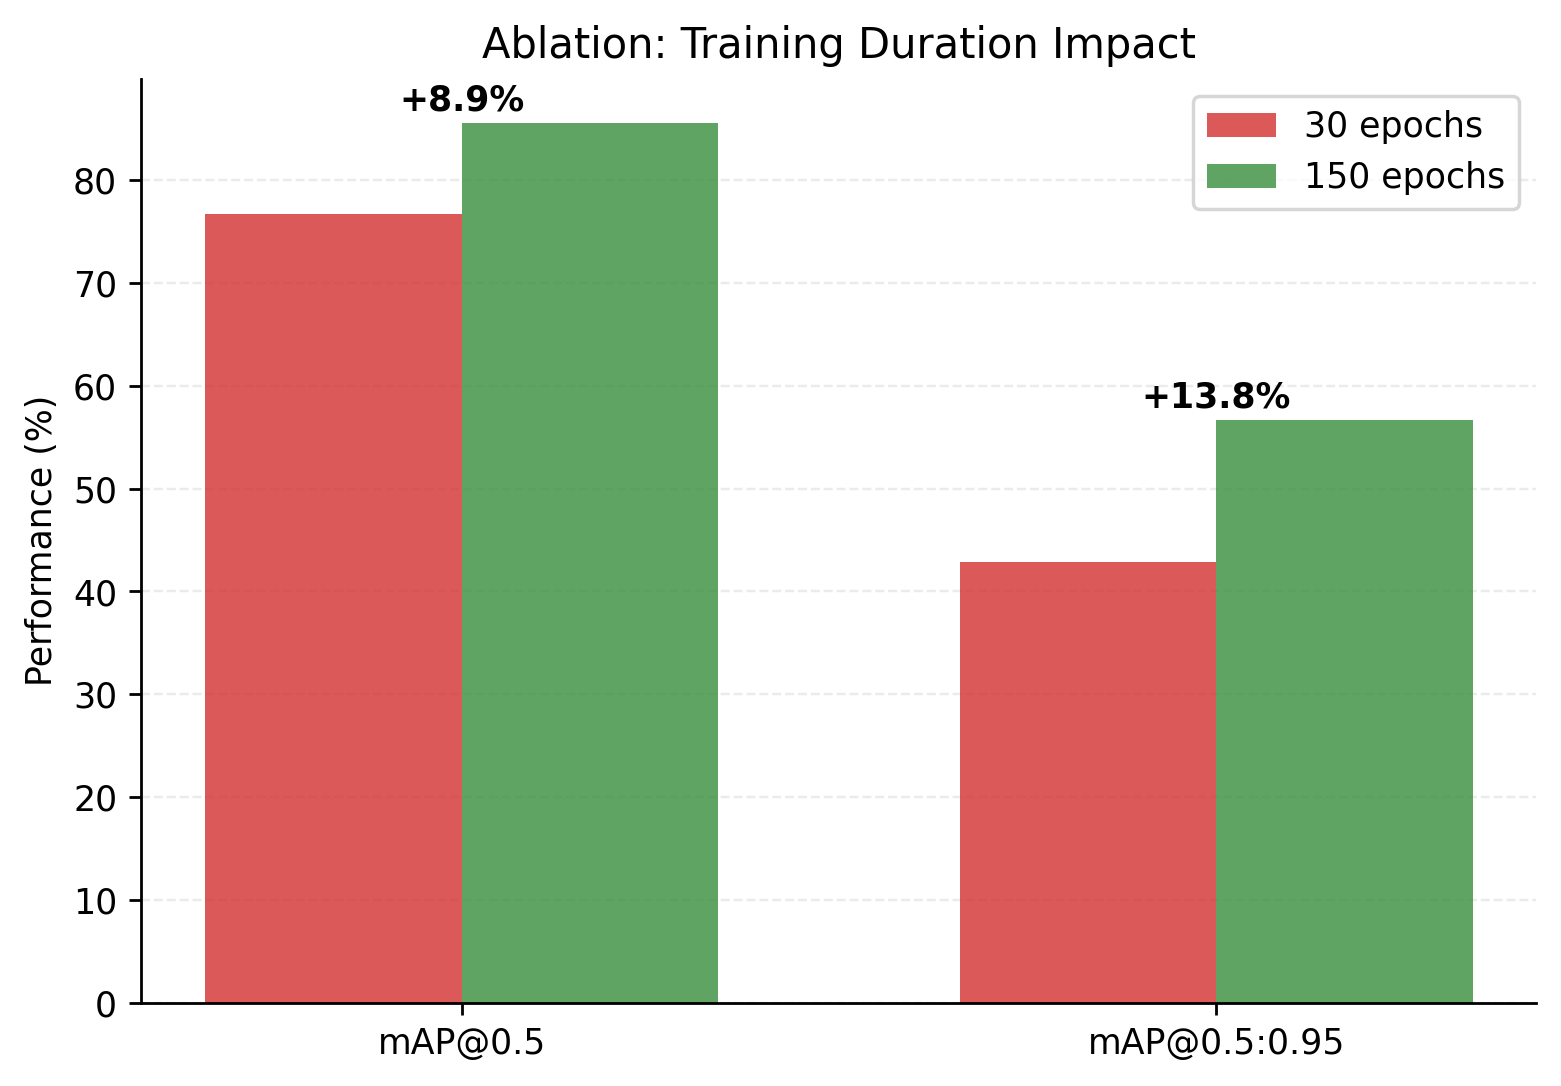

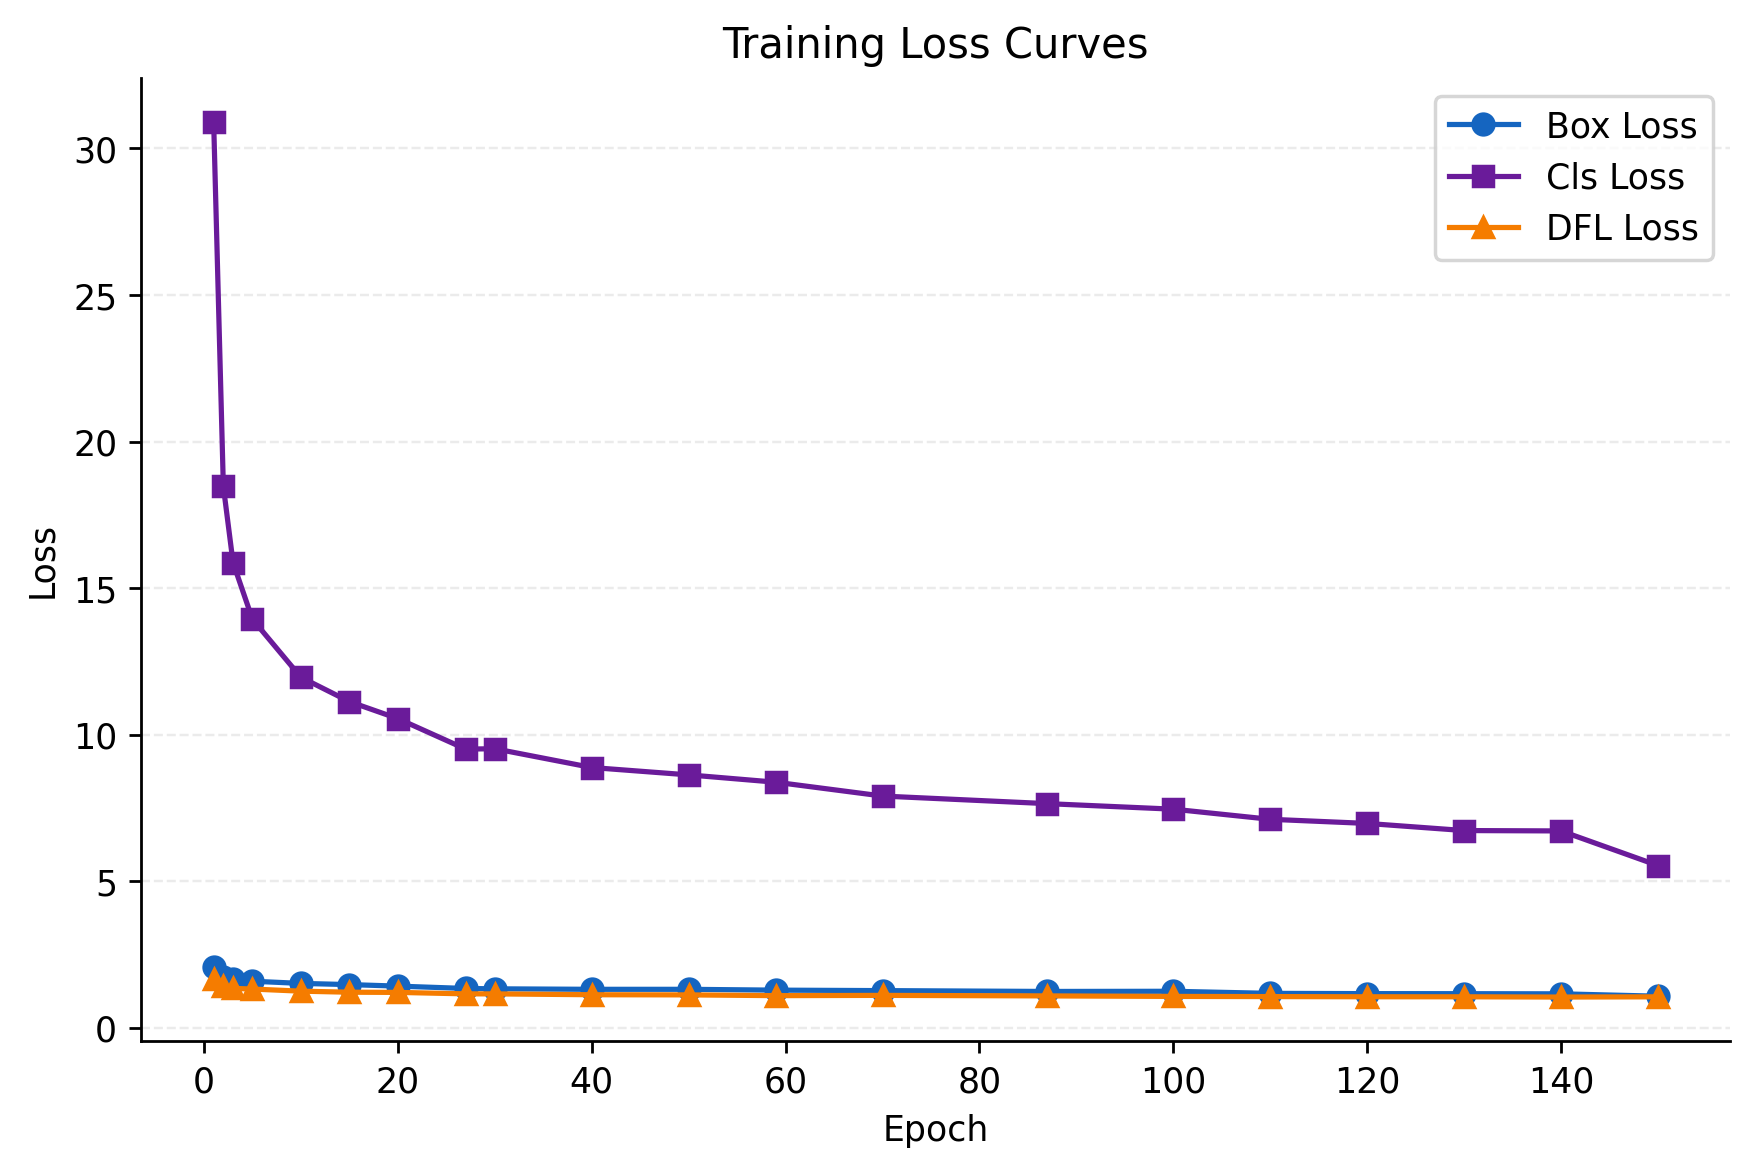

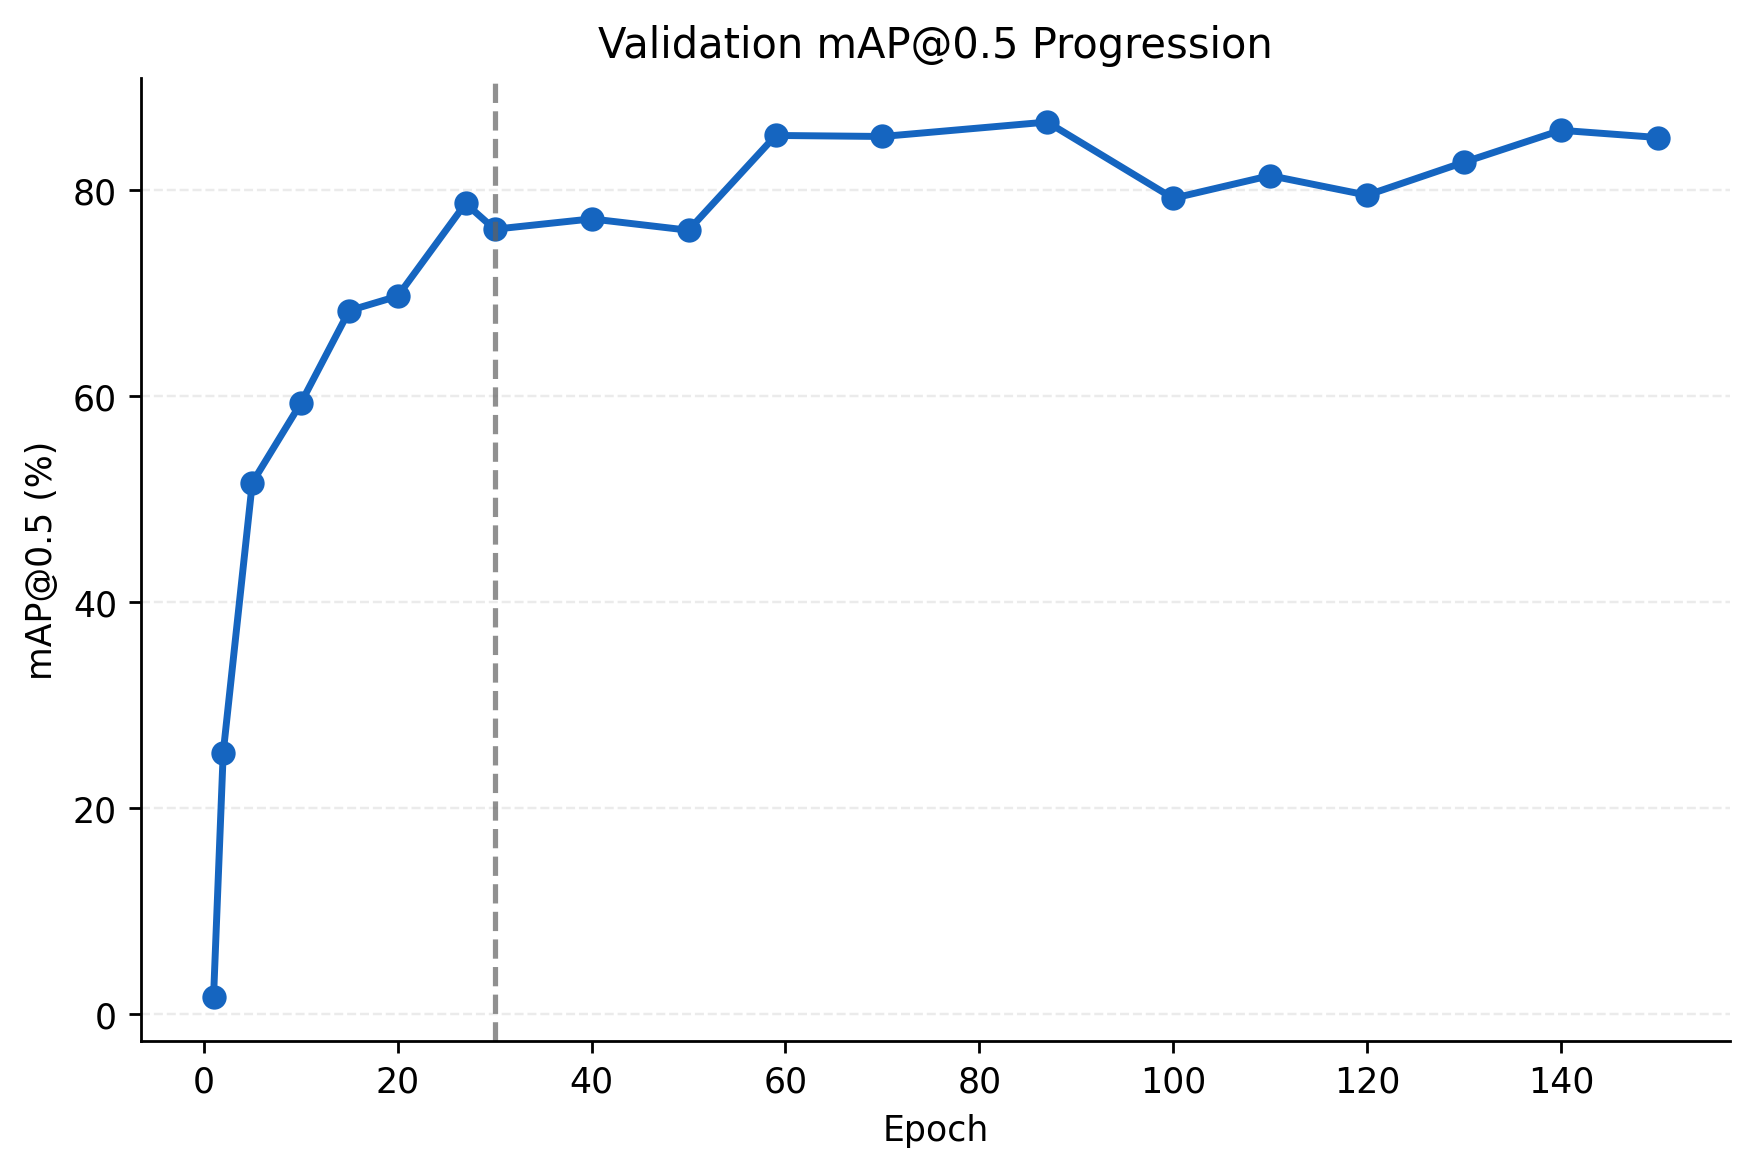

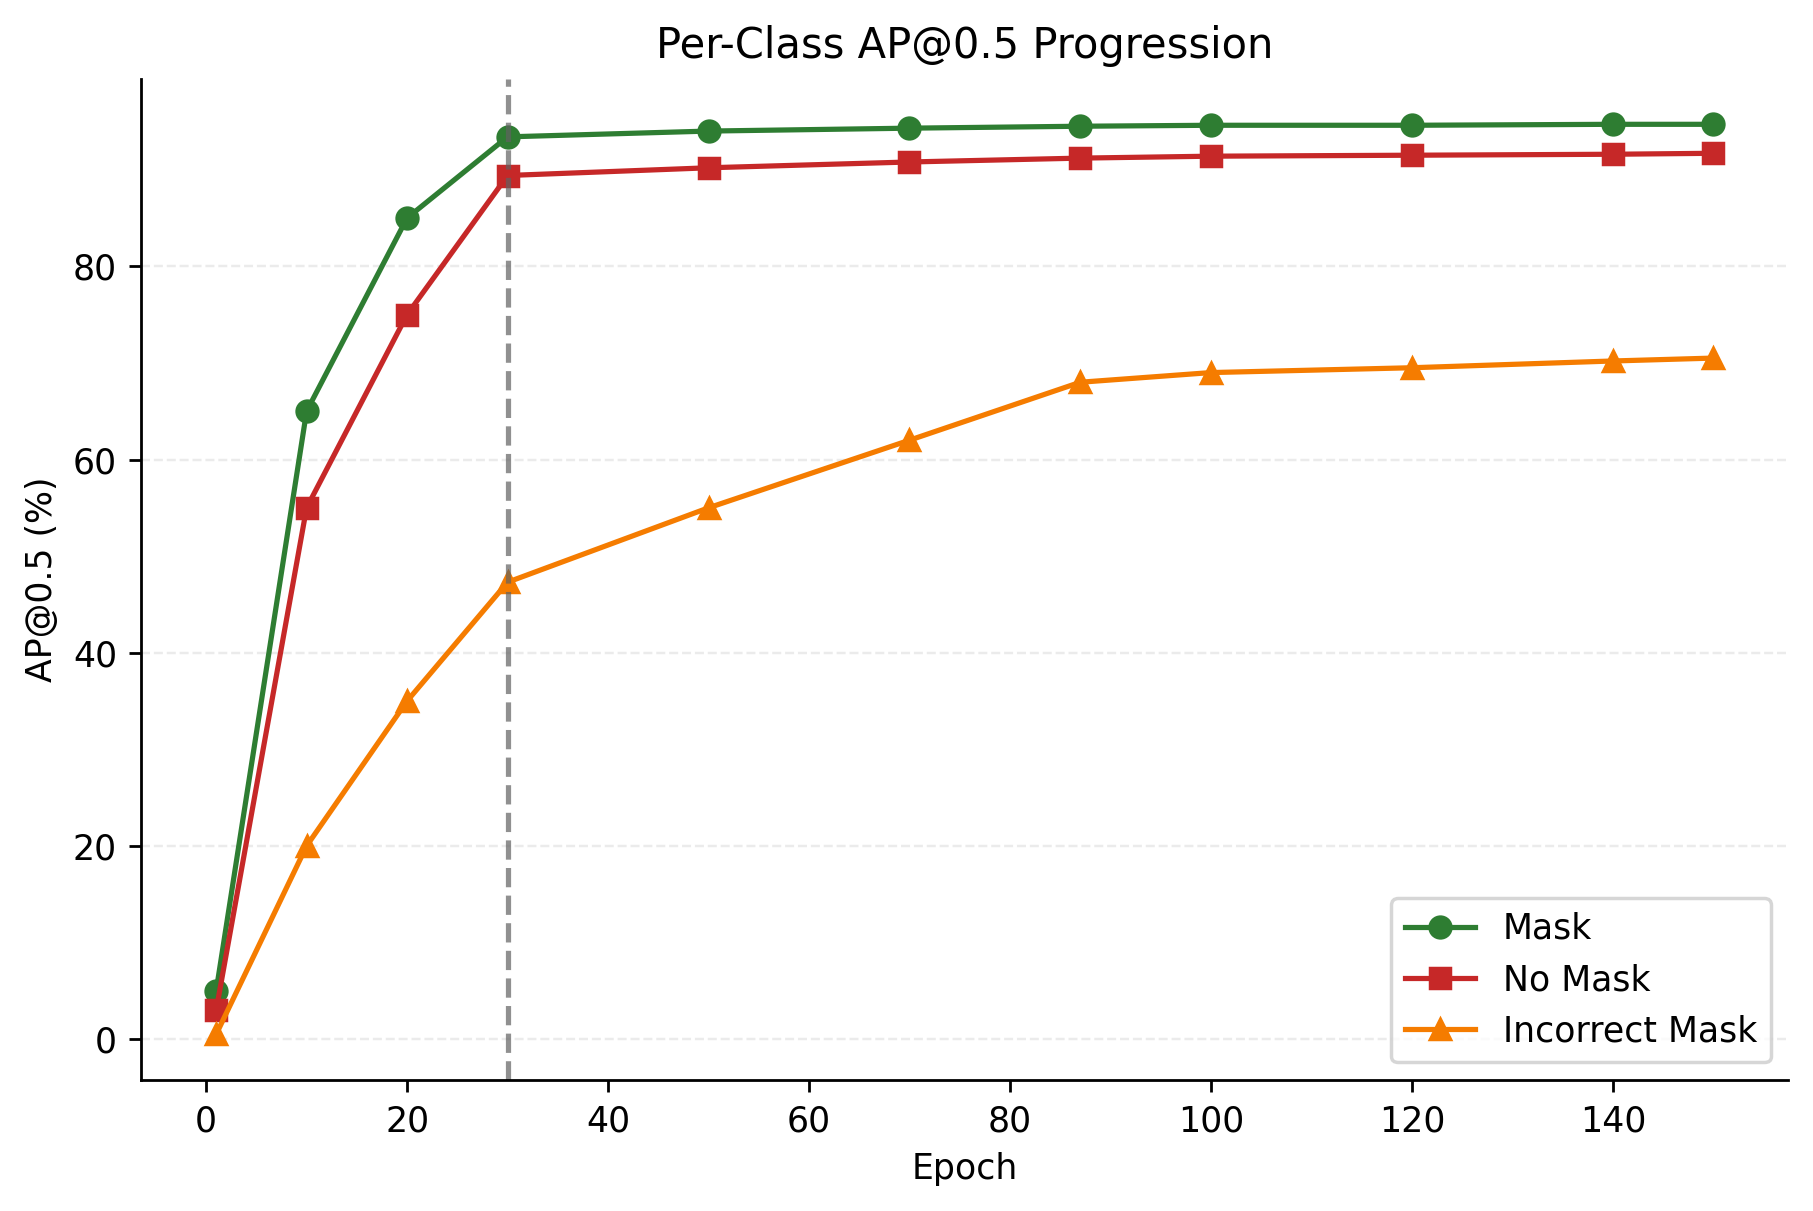

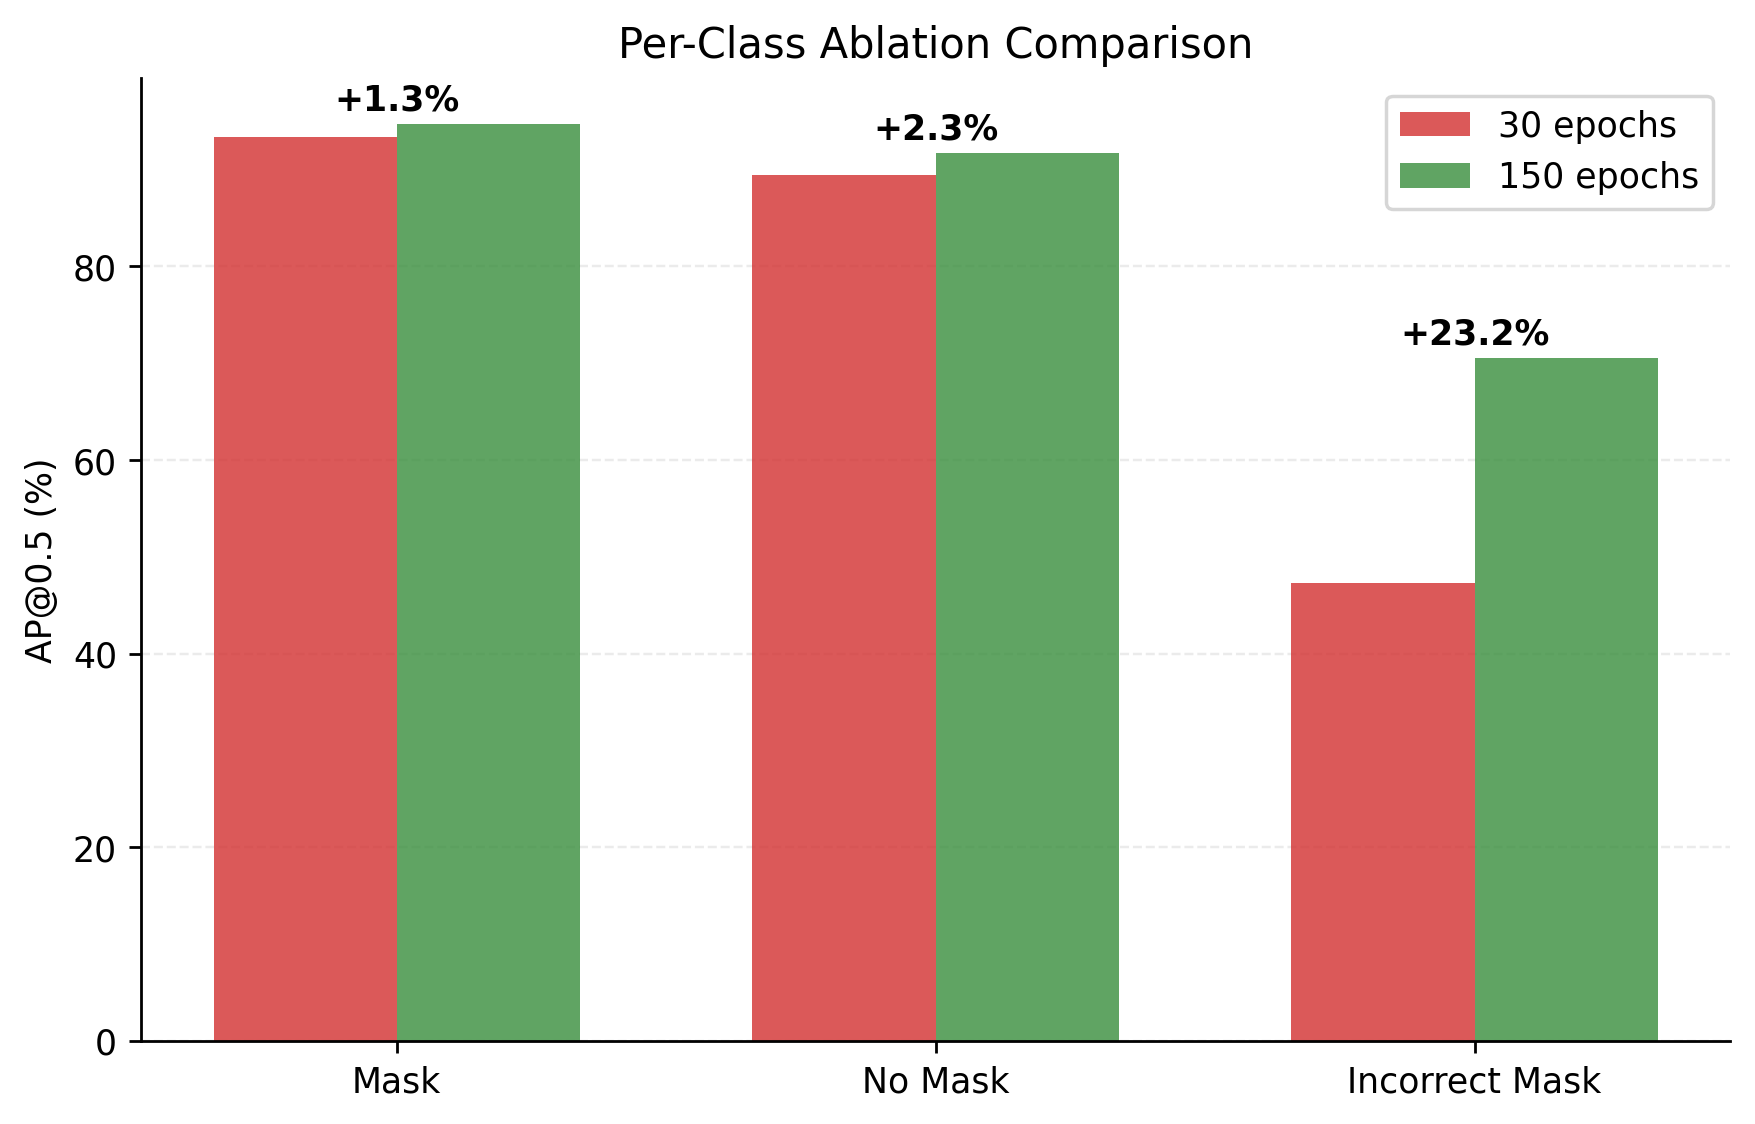

In [39]:
# ============================================
# 13B. Visulizations
# ============================================
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({
    "figure.dpi": 250,
    "savefig.dpi": 250,
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

COLORS = {
    "mask": "#2E7D32",
    "no_mask": "#C62828",
    "incorrect": "#F57C00",
    "primary": "#1565C0",
    "secondary": "#6A1B9A",
    "gray": "#616161",
}

def soft_grid(ax):
    ax.grid(True, axis="y", linestyle="--", linewidth=0.7, alpha=0.25)
    ax.set_axisbelow(True)

# Figure 1: Class distribution
classes = ["Mask", "No Mask", "Incorrect Mask"]
instances = np.array([3011, 668, 115])
pct = np.array([79.4, 17.6, 3.0])

fig, ax = plt.subplots(figsize=(7.5, 4.8))
bars = ax.bar(classes, instances, color=[COLORS["mask"], COLORS["no_mask"], COLORS["incorrect"]])
for b, v, p in zip(bars, instances, pct):
    ax.text(b.get_x() + b.get_width()/2, v + 80, f"{v:,} ({p:.1f}%)", ha="center", va="bottom")
ax.set_title("Class Distribution")
ax.set_ylabel("Instances")
soft_grid(ax)
plt.show()

# Figure 2: Ablation comparison
metrics = ["mAP@0.5", "mAP@0.5:0.95"]
baseline_30 = np.array([76.7, 42.9])
extended_150 = np.array([85.6, 56.7])

fig, ax = plt.subplots(figsize=(7.2, 4.8))
x = np.arange(len(metrics))
w = 0.34
ax.bar(x - w/2, baseline_30, width=w, label="30 epochs", color="#D32F2F", alpha=0.8)
ax.bar(x + w/2, extended_150, width=w, label="150 epochs", color="#388E3C", alpha=0.8)
for i, (a, b) in enumerate(zip(baseline_30, extended_150)):
    ax.text(i, max(a, b) + 1.2, f"+{(b-a):.1f}%", ha="center", fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylabel("Performance (%)")
ax.set_title("Ablation: Training Duration Impact")
ax.legend()
soft_grid(ax)
plt.show()

# Figure 3: Training loss curves
epochs = np.array([1, 2, 3, 5, 10, 15, 20, 27, 30, 40, 50, 59, 70, 87, 100, 110, 120, 130, 140, 150])
box_loss = np.array([2.068, 1.739, 1.651, 1.591, 1.517, 1.476, 1.424, 1.344, 1.332, 1.315, 1.315, 1.287, 1.271, 1.242, 1.248, 1.177, 1.168, 1.166, 1.161, 1.080])
cls_loss = np.array([30.9, 18.47, 15.87, 13.94, 11.96, 11.13, 10.55, 9.51, 9.522, 8.881, 8.63, 8.38, 7.908, 7.649, 7.46, 7.115, 6.974, 6.731, 6.718, 5.538])
dfl_loss = np.array([1.677, 1.419, 1.347, 1.324, 1.252, 1.216, 1.21, 1.16, 1.159, 1.13, 1.125, 1.099, 1.108, 1.09, 1.073, 1.067, 1.061, 1.06, 1.051, 1.059])

fig, ax = plt.subplots(figsize=(8.2, 5.0))
ax.plot(epochs, box_loss, marker="o", label="Box Loss", color=COLORS["primary"])
ax.plot(epochs, cls_loss, marker="s", label="Cls Loss", color=COLORS["secondary"])
ax.plot(epochs, dfl_loss, marker="^", label="DFL Loss", color=COLORS["incorrect"])
ax.set_title("Training Loss Curves")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.legend()
soft_grid(ax)
plt.show()

# Figure 4: Validation mAP progression
map_epochs = np.array([1, 2, 5, 10, 15, 20, 27, 30, 40, 50, 59, 70, 87, 100, 110, 120, 130, 140, 150])
map_values = np.array([1.67, 25.4, 51.6, 59.3, 68.3, 69.7, 78.7, 76.2, 77.2, 76.1, 85.3, 85.2, 86.6, 79.2, 81.4, 79.5, 82.7, 85.8, 85.1])

fig, ax = plt.subplots(figsize=(8.2, 5.0))
ax.plot(map_epochs, map_values, marker="o", color=COLORS["primary"], linewidth=2)
ax.axvline(30, linestyle="--", color=COLORS["gray"], alpha=0.7)
ax.set_title("Validation mAP@0.5 Progression")
ax.set_xlabel("Epoch")
ax.set_ylabel("mAP@0.5 (%)")
soft_grid(ax)
plt.show()

# Figure 5: Per-class AP progression
epochs_pc = np.array([1, 10, 20, 30, 50, 70, 87, 100, 120, 140, 150])
mask_ap = np.array([5, 65, 85, 93.4, 94.0, 94.3, 94.5, 94.6, 94.6, 94.7, 94.7])
no_mask_ap = np.array([3, 55, 75, 89.4, 90.2, 90.8, 91.2, 91.4, 91.5, 91.6, 91.7])
incorrect_ap = np.array([0.5, 20, 35, 47.3, 55, 62, 68, 69, 69.5, 70.2, 70.5])

fig, ax = plt.subplots(figsize=(8.5, 5.2))
ax.plot(epochs_pc, mask_ap, marker="o", label="Mask", color=COLORS["mask"])
ax.plot(epochs_pc, no_mask_ap, marker="s", label="No Mask", color=COLORS["no_mask"])
ax.plot(epochs_pc, incorrect_ap, marker="^", label="Incorrect Mask", color=COLORS["incorrect"])
ax.axvline(30, linestyle="--", color=COLORS["gray"], alpha=0.7)
ax.set_title("Per-Class AP@0.5 Progression")
ax.set_xlabel("Epoch")
ax.set_ylabel("AP@0.5 (%)")
ax.legend()
soft_grid(ax)
plt.show()

# Figure 6: Per-class ablation
classes = ["Mask", "No Mask", "Incorrect Mask"]
baseline_30 = np.array([93.4, 89.4, 47.3])
extended_150 = np.array([94.7, 91.7, 70.5])

fig, ax = plt.subplots(figsize=(8.2, 5.0))
x = np.arange(len(classes))
w = 0.34
ax.bar(x - w/2, baseline_30, width=w, label="30 epochs", color="#D32F2F", alpha=0.8)
ax.bar(x + w/2, extended_150, width=w, label="150 epochs", color="#388E3C", alpha=0.8)
for i, (a, b) in enumerate(zip(baseline_30, extended_150)):
    ax.text(i, max(a, b) + 1.5, f"+{(b-a):.1f}%", ha="center", fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(classes)
ax.set_ylabel("AP@0.5 (%)")
ax.set_title("Per-Class Ablation Comparison")
ax.legend()
soft_grid(ax)
plt.show()


In [3]:
!pip install flask flask-ngrok pyngrok ultralytics

In [4]:
!pip install opencv-python-headless

In [5]:
from flask import Flask, request, jsonify, send_from_directory
from flask_cors import CORS
from ultralytics import YOLO
import os
import uuid
import cv2

app = Flask(__name__)
CORS(app, resources={r"/*": {"origins": "*"}})

@app.after_request
def after_request(response):
    response.headers.add('Access-Control-Allow-Origin', '*')
    response.headers.add('Access-Control-Allow-Headers', 'Content-Type,Authorization')
    response.headers.add('Access-Control-Allow-Methods', 'GET,POST,OPTIONS')
    return response

model = YOLO('/content/runs/detect/runs/detect/maskguard_clean/weights/best.pt')

UPLOAD_FOLDER = "uploads"
RESULT_FOLDER = "results"

os.makedirs(UPLOAD_FOLDER, exist_ok=True)
os.makedirs(RESULT_FOLDER, exist_ok=True)

@app.route('/')
def home():
    return "Server Running"

@app.route('/results/<filename>')
def get_result_image(filename):
    return send_from_directory(RESULT_FOLDER, filename)

@app.route('/predict', methods=['POST', 'OPTIONS'])
def predict():
    if request.method == 'OPTIONS':
        return '', 200

    if 'image' not in request.files:
        return jsonify({"result": "No image uploaded"})

    file = request.files['image']

    if file.filename == '':
        return jsonify({"result": "No selected image"})

    unique_name = str(uuid.uuid4()) + ".jpg"
    filepath = os.path.join(UPLOAD_FOLDER, unique_name)
    file.save(filepath)

    results = model(filepath)

    plotted_image = results[0].plot()

    result_filename = "result_" + unique_name
    result_path = os.path.join(RESULT_FOLDER, result_filename)

    plotted_image_bgr = cv2.cvtColor(plotted_image, cv2.COLOR_RGB2BGR)
    cv2.imwrite(result_path, plotted_image_bgr)

    image_url = request.host_url + "results/" + result_filename

    return jsonify({
        "result": "Prediction completed",
        "image_url": image_url
    })

In [1]:
!fuser -k 5001/tcp

In [6]:
from pyngrok import ngrok
import threading

ngrok.kill()

public_url = ngrok.connect(5001)
print("Public URL:", public_url)

threading.Thread(
    target=lambda: app.run(
        host='0.0.0.0',
        port=5001,
        debug=False,
        use_reloader=False
    )
).start()

Public URL: NgrokTunnel: "https://sharilyn-sensitive-leisha.ngrok-free.dev" -> "http://localhost:5001"
 * Serving Flask app '__main__'
 * Debug mode: off
